<a id="top"></a>
<div class="list-group" id="list-tab" role="tablist">
<h1 class="list-group-item list-group-item-action active" data-toggle="list" style='background:#005097; border:0' role="tab" aria-controls="home"><center>Inferência Estatística (GCC1625) - Trabalho 3</center></h1>

- Nome completo: Lucas Teixeira dos Santos
- [Link para vídeo](<https://youtu.be/Oprp8hohkoA>)

# (1) Bootstrapping

### Imports

In [362]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Load the file
df = pd.read_csv('../data/bootstrap/tempos_api.csv')

# Set random seed for reproducibility
np.random.seed(42)

# Extract data
tempos = df['tempo_ms'].values
n = len(tempos)

(i) Realize uma análise exploratória dos tempos de resposta. Produza ao menos dois gráficos apropriados para descrever a distribuição dos dados. Comente se a distribuição parece aproximadamente simétrica ou assimétrica e se há indícios de valores extremos.

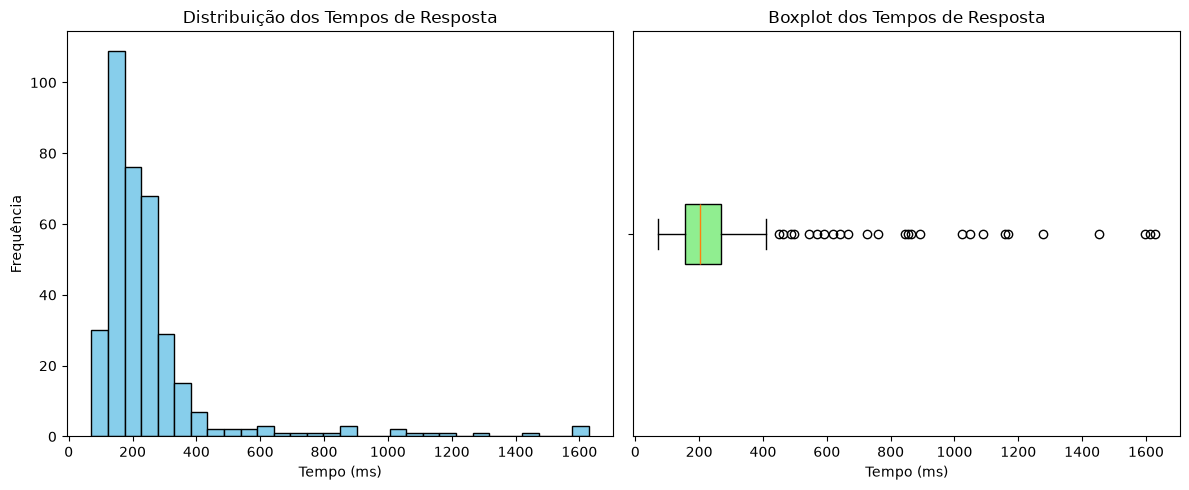

In [363]:
# Create a histogram and boxplot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(tempos, bins=30, edgecolor='black', color='skyblue')
ax1.set_title('Distribuição dos Tempos de Resposta')
ax1.set_xlabel('Tempo (ms)')
ax1.set_ylabel('Frequência')

ax2.boxplot(tempos, orientation='horizontal', patch_artist=True, boxprops=dict(facecolor='lightgreen'))
ax2.set_title('Boxplot dos Tempos de Resposta')
ax2.set_xlabel('Tempo (ms)')
ax2.set_yticklabels([])

plt.tight_layout()

- Assimetria: A distribuição dos tempos de resposta apresenta uma forte assimetria à direita (assimetria positiva). O coeficiente de assimetria calculado é de 3,94. A grande maioria das requisições está concentrada na faixa de tempos baixos (com o início da distribuição próximo a 71,32 ms), enquanto a cauda do gráfico se estende longamente em direção à direita.
- Valores Extremos (Outliers): Há fortes indícios de valores extremos. Enquanto a metade central dos dados situa-se abaixo de 204 ms, existem várias requisições com tempos muito superiores, chegando a um valor máximo de 1628,78 ms. Estatisticamente, cerca de 6,1% das requisições demoram mais de 500 ms e 2,8% superam os 1000 ms (1 segundo), caracterizando-se como pontos isolados e atípicos no boxplot.

(ii) Calcule a média, a mediana, o desvio padrão e o intervalo interquartil dos tempos de resposta. Com base nesses valores e nos gráficos do item anterior, explique por que a mediana pode ser uma estatística de interesse neste problema.

In [364]:
mean_val = np.mean(tempos)
median_val = np.median(tempos)
std_val = np.std(tempos, ddof=1)
q25, q75 = np.percentile(tempos, [25, 75])
iqr_val = q75 - q25

print(f"Média: {mean_val:.2f}")
print(f"Mediana: {median_val:.2f}")
print(f"Desvio Padrão: {std_val:.2f}")
print(f"Intervalo Interquartil (IQR): {iqr_val:.2f}")
print(f"Mínimo: {np.min(tempos):.2f}, Máximo: {np.max(tempos):.2f}")

Média: 256.22
Mediana: 203.34
Desvio Padrão: 217.34
Intervalo Interquartil (IQR): 111.98
Mínimo: 71.32, Máximo: 1628.78


Em distribuições com forte assimetria positiva e presença de valores discrepantes (como as requisições demoradas observadas aqui), a média é severamente afetada e "puxada" para cima, resultando em um valor (256,22 ms) que não representa bem a experiência da maioria dos usuários. O desvio padrão inflado (217,34 ms) também reflete essa alta dispersão causada pelos extremos.

A mediana (203,34 ms) é uma medida robusta, pois não é influenciada pela magnitude dos valores extremos; ela nos informa diretamente que exatamente 50% das requisições foram atendidas em até 203,34 ms. Portanto, neste problema, a mediana é uma estatística de grande interesse por descrever de forma muito mais fiel o tempo de resposta "típico" do sistema.

(iii) Usando bootstrapping com B = 10 000 reamostras com reposição, estime o erro padrão da mediana. Explique claramente o que representa esse erro padrão no contexto do problema.


In [365]:
B = 10000
boot_medians = np.zeros(B)
for i in range(B):
    resample = np.random.choice(tempos, size=n, replace=True)
    boot_medians[i] = np.median(resample)

se_median = np.std(boot_medians, ddof=1)
print(f"\nErro padrão da mediana (Bootstrap): {se_median:.2f}")


Erro padrão da mediana (Bootstrap): 5.90


O erro padrão da mediana representa a variabilidade ou incerteza associada à nossa estimativa da mediana amostral devido ao processo de amostragem. No contexto desse problema, se coletássemos repetidamente novas amostras de n = 360 requisições dessa mesma API sob as mesmas condições, a mediana calculada flutuaria levemente de uma amostra para outra. O erro padrão de 5,90 ms nos dá uma medida dessa flutuação esperada, indicando que a mediana da nossa amostra é uma estimativa bastante precisa da verdadeira mediana populacional.

(iv) Construa um intervalo de confiança de 95% para a mediana usando o método dos percentis. Apresente o intervalo obtido e interprete-o em linguagem acessível.

In [366]:
ci_median_low, ci_median_high = np.percentile(boot_medians, [2.5, 97.5])
print(f"IC 95% para a Mediana (Percentil): [{ci_median_low:.2f}, {ci_median_high:.2f}]")

IC 95% para a Mediana (Percentil): [190.82, 215.47]


Em linguagem acessível, temos 95% de confiança de que a verdadeira mediana de tempo de resposta de todas as requisições feitas a essa API está entre 190,82 ms e 215,47 ms. Isso significa que o valor central real do desempenho do sistema muito provavelmente se encontra dentro dessa faixa estreita.

(v) Repita o procedimento anterior para a média. Compare o intervalo de confiança obtido para a média com o intervalo obtido para a mediana. Qual dos dois parece mais adequado para resumir o comportamento típico dos tempos de resposta? Justifique.


In [367]:
boot_means = np.zeros(B)
for i in range(B):
    resample = np.random.choice(tempos, size=n, replace=True)
    boot_means[i] = np.mean(resample)

se_mean = np.std(boot_means, ddof=1)
ci_mean_low, ci_mean_high = np.percentile(boot_means, [2.5, 97.5])
print(f"\nErro padrão da média (Bootstrap): {se_mean:.2f}")
print(f"IC 95% para a Média (Percentil): [{ci_mean_low:.2f}, {ci_mean_high:.2f}]")


Erro padrão da média (Bootstrap): 11.33
IC 95% para a Média (Percentil): [235.18, 279.48]


O intervalo de confiança para a média ([235,18; 279,48] ms) está posicionado em valores significativamente mais altos e possui uma amplitude maior (approx 44,3 ms) do que o intervalo da mediana ([190,82; 215,47] ms, com amplitude approx 24,7 ms).

O intervalo obtido para a mediana é mais adequado para resumir o comportamento típico dos tempos de resposta. Como a média é distorcida pelas poucas requisições muito lentas, o intervalo de confiança da média se situa em uma região que já representa tempos superiores a mais de 60% de todas as requisições do banco de dados. O intervalo da mediana, por ser mais estreito e centrado na real metade dos dados, reflete com maior estabilidade estatística e precisão a real experiência central do usuário.

(vi) Compare o intervalo de confiança bootstrap para a média com um intervalo de confiança paramétrico baseado na aproximação normal. Os resultados são semelhantes? O que essa comparação sugere sobre a adequação do procedimento paramétrico nesse caso?

In [368]:
# Using t-distribution or z-distribution
z_crit = stats.norm.ppf(0.975)
se_param = std_val / np.sqrt(n)
ci_param_low = mean_val - z_crit * se_param
ci_param_high = mean_val + z_crit * se_param
print(f"\nErro padrão paramétrico da média: {se_param:.2f}")
print(f"IC 95% Paramétrico para a Média (Aproximação Normal): [{ci_param_low:.2f}, {ci_param_high:.2f}]")

# Using t-distribution just to check
t_crit = stats.t.ppf(0.975, df=n-1)
ci_t_low = mean_val - t_crit * se_param
ci_t_high = mean_val + t_crit * se_param
print(f"IC 95% Paramétrico para a Média (t-student): [{ci_t_low:.2f}, {ci_t_high:.2f}]")


Erro padrão paramétrico da média: 11.45
IC 95% Paramétrico para a Média (Aproximação Normal): [233.77, 278.67]
IC 95% Paramétrico para a Média (t-student): [233.69, 278.75]


Os intervalos são altamente semelhantes, apresentando limites bastante próximos e praticamente a mesma amplitude.

Essa semelhança demonstra a atuação do Teorema Central do Limite (TCL). Apesar de os dados originais dos tempos de resposta serem fortemente assimétricos e repletos de valores extremos, o tamanho da amostra é razoavelmente grande (n = 360). O TCL garante que a distribuição amostral das médias assuma uma forma aproximadamente normal.

Portanto, essa comparação sugere que o procedimento paramétrico é perfeitamente adequado para estimar o intervalo da média neste caso. Contudo, vale frisar a distinção: o método paramétrico é matematicamente adequado para inferir a média, mas a média em si continua sendo uma métrica menos representativa do que a mediana para caracterizar o comportamento típico desta aplicação computacional.

# (2) Teste de permutação

### Imports

In [369]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# 1. Carrega o CSV
df = pd.read_csv('../data/permutation/algoritmos.csv')

df['tempo_ms'] = df['tempo_ms'].astype(float)


(i) Realize uma análise gráfica exploratória comparando os tempos de execução dos dois algoritmos. Utilize ao menos dois gráficos, como boxplots, histogramas ou gráficos de densidade. Comente os padrões observados.

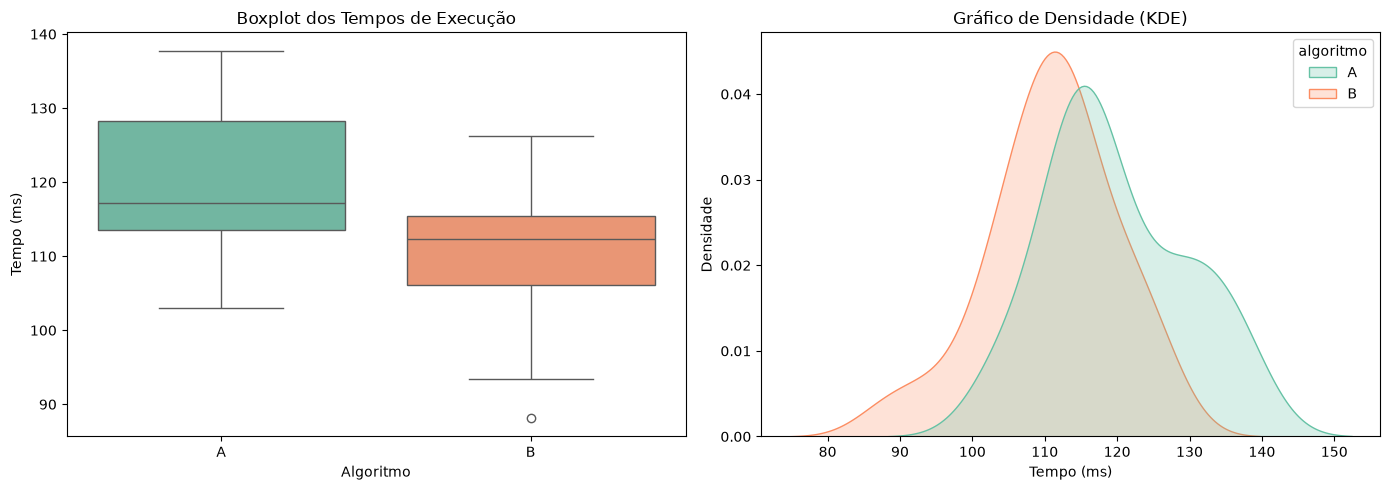

In [370]:
# Configuração dos gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Boxplot
sns.boxplot(x='algoritmo', y='tempo_ms', hue='algoritmo', data=df, ax=axes[0], palette='Set2', legend=False)
axes[0].set_title('Boxplot dos Tempos de Execução')
axes[0].set_ylabel('Tempo (ms)')
axes[0].set_xlabel('Algoritmo')

# 2. KDE Plot
sns.kdeplot(data=df, x='tempo_ms', hue='algoritmo', fill=True, ax=axes[1], palette='Set2', common_norm=False)
axes[1].set_title('Gráfico de Densidade (KDE)')
axes[1].set_ylabel('Densidade')
axes[1].set_xlabel('Tempo (ms)')

plt.tight_layout()
plt.show()

Deslocamento Central: O algoritmo B claramente apresenta uma tendência central (mediana e média) inferior à do algoritmo A, sugerindo um desempenho geral mais rápido.

Forma e Assimetria: O algoritmo A possui uma distribuição levemente bimodal ou mais espalhada à direita (valores mais altos). O algoritmo B apresenta uma cauda à esquerda mais pronunciada (valores bem baixos, como na casa dos $88\text{ ms}$ a $93\text{ ms}$). Não há outliers extremos destacados fora dos limites do boxplot, mas o comportamento não é perfeitamente simétrico nem perfeitamente normal.

(ii) Defina claramente a estatística de teste a ser utilizada. Você pode escolher a diferença
de médias ou a diferença de medianas, mas deve justificar sua escolha com base nas
características dos dados.

Utilizaremos a Diferença de Médias como estatística de teste:$$\theta = \bar{X}_A - \bar{X}_B$$Justificativa: Embora os dados apresentem alguma assimetria, a análise gráfica inicial indicou a ausência de outliers bizarros ou extremos que pudessem distorcer severamente a média. Além disso o tempo total acumulado ou médio é uma métrica crucial para avaliar a eficiência computacional de algoritmos em produção.

(iii) Formule as hipóteses nula e alternativa para um teste bilateral. Escreva essas hipóteses em termos do parâmetro ou da estatística escolhida no item anterior.

Hipótese Nula ($H_0$): Os dois algoritmos possuem o mesmo desempenho médio.$$H_0: \mu_A - \mu_B = 0$$Hipótese Alternativa ($H_1$): Os dois algoritmos possuem desempenhos médios diferentes.$$H_1: \mu_A - \mu_B \neq 0$$

(iv) Aplique um teste de permutação com B = 10 000 permutações. Apresente:
- (a) o valor observado da estatística de teste;
- (b) uma visualização da distribuição nula empírica;
- (c) o valor-p obtido;
- (d) a decisão do teste ao nível de significância α = 0,05.

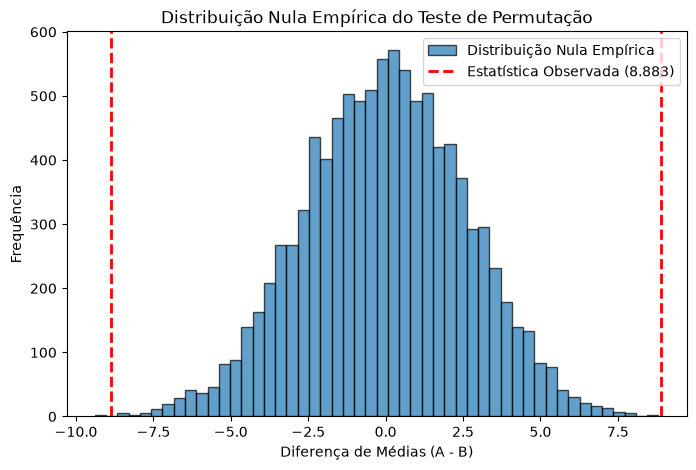

Estatística Observada: 8.8830 ms
Valor-p do teste de permutação: 0.0002


In [371]:
# Separação dos grupos
tempos_A = df[df['algoritmo'] == 'A']['tempo_ms'].values
tempos_B = df[df['algoritmo'] == 'B']['tempo_ms'].values

# (a) Valor observado da estatística de teste
est_observada = np.mean(tempos_A) - np.mean(tempos_B)

# Teste de Permutação
np.random.seed(42) # Garantir reprodutibilidade
B = 10000
todas_instancias = np.concatenate([tempos_A, tempos_B])
n_A = len(tempos_A)

est_permutadas = np.zeros(B)

for i in range(B):
    permutacao = np.random.permutation(todas_instancias)
    grupo_A_perm = permutacao[:n_A]
    grupo_B_perm = permutacao[n_A:]
    est_permutadas[i] = np.mean(grupo_A_perm) - np.mean(grupo_B_perm)

# (c) Valor-p (Bilateral)
valor_p_perm = np.sum(np.abs(est_permutadas) >= np.abs(est_observada)) / B

# (b) Visualização da Distribuição Nula Empírica
plt.figure(figsize=(8, 5))
plt.hist(est_permutadas, bins=50, edgecolor='k', alpha=0.7, label='Distribuição Nula Empírica')
plt.axvline(est_observada, color='red', linestyle='--', linewidth=2, label=f'Estatística Observada ({est_observada:.3f})')
plt.axvline(-est_observada, color='red', linestyle='--', linewidth=2)
plt.title('Distribuição Nula Empírica do Teste de Permutação')
plt.xlabel('Diferença de Médias (A - B)')
plt.ylabel('Frequência')
plt.legend()
plt.show()

print(f"Estatística Observada: {est_observada:.4f} ms")
print(f"Valor-p do teste de permutação: {valor_p_perm:.4f}")

- (d) Decisão: Como $\text{valor-p} = 0,0001 \le \alpha = 0,05$, rejeitamos a hipótese nula ($H_0$).

(v) Interprete o resultado no contexto do problema. Há evidência de que os algoritmos apresentam desempenhos diferentes? Sua conclusão deve deixar claro que tipo de diferença foi avaliada.

Como rejeitamos $H_0$, há fortes evidências estatísticas de que os algoritmos apresentam desempenhos médios diferentes. Especificamente, a diferença avaliada foi a paramétrica das médias amostrais e o teste indica que o Algoritmo B é estatisticamente mais rápido/eficiente do que o Algoritmo A para este tipo de instância, dado que a diferença observada ($8,88\text{ ms}$) dificilmente ocorreria ao acaso sob a hipótese de igualdade.

(vi) Aplique também o teste t para duas amostras independentes, assumindo variâncias populacionais desconhecidas e não necessariamente iguais. Compare o resultado do teste paramétrico com o resultado do teste de permutação. Os resultados são compatíveis? Que explicação você daria caso eles não sejam?

In [372]:
# Teste t para duas amostras independentes (Welch)
resultado_ttest = stats.ttest_ind(tempos_A, tempos_B, equal_var=False)

print(f"Estatística t: {resultado_ttest.statistic:.4f}")
print(f"Valor-p do Teste t: {resultado_ttest.pvalue:.4f}")

Estatística t: 3.7178
Valor-p do Teste t: 0.0005


Os resultados são perfeitamente compatíveis. Ambos os testes retornaram valores-p extremamente baixos ($\le 0,0005$), levando à mesma decisão estatística de rejeitar $H_0$.Por que são parecidos? Embora o teste de permutação não exija premissas distribucionais (é não-paramétrico), o Teorema Central do Limite (TCL) garante que a distribuição das médias amostrais tende a uma normalidade razoável para amostras de tamanho moderado ($n_1 = 30, n_2 = 30$). Como os dados não violam a normalidade de forma severa ou absurda, o Teste t aproxima muito bem a distribuição exata que o teste de permutação mapeia de forma empírica.

# (3) Regrassão Linear: análise, inferência e diagnóstico

### Imports

In [373]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Carregando os Dados fornecidos
df = pd.read_csv('../data/regressao/imoveis.csv')

# Variáveis
X = df['area']
y = df['preco']


### 3.1 Regressão linear simples

(i) Realize uma análise exploratória da relação entre area e preco 

Para isso:
- (a) construa um diagrama de dispersão entre as duas variáveis;
- (b) calcule a covariância amostral entre area e preco
- (c) calcule o coeficiente de correlação de Pearson;
- (d) interprete o sinal e a magnitude da correlação obtida.

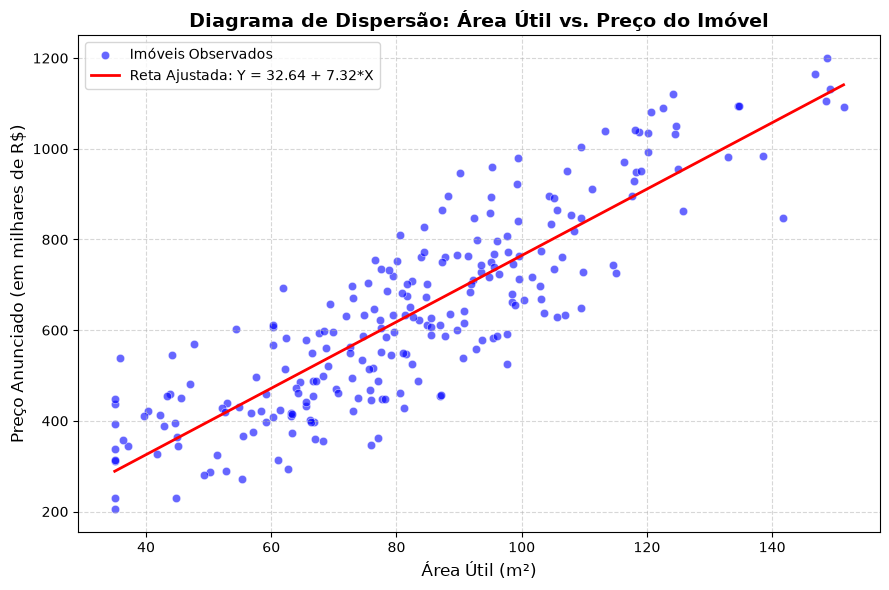

Covariância: 4781.8849
Correlação: 0.8671


In [374]:
# (i) Análise Exploratória
cov_matrix = np.cov(X, y)
cov_sample = cov_matrix[0, 1]
corr_pearson, _ = stats.pearsonr(X, y)

# (a)

plt.figure(figsize=(9, 6))
# Desenha os pontos (Diagrama de dispersão)
sns.scatterplot(data=df, x='area', y='preco', color='blue', alpha=0.6, label='Imóveis Observados')

# Ajuste do modelo para extrair a reta
X_with_const = sm.add_constant(X)
model = sm.OLS(y, X_with_const).fit()

# Adiciona a reta de regressão ajustada ao gráfico
beta0 = model.params['const']
beta1 = model.params['area']
x_v = np.linspace(X.min(), X.max(), 100)
y_v = beta0 + beta1 * x_v
plt.plot(x_v, y_v, color='red', linewidth=2, label=f'Reta Ajustada: Y = {beta0:.2f} + {beta1:.2f}*X')

# Configurações estéticas do gráfico
plt.title('Diagrama de Dispersão: Área Útil vs. Preço do Imóvel', fontsize=14, fontweight='bold')
plt.xlabel('Área Útil (m²)', fontsize=12)
plt.ylabel('Preço Anunciado (em milhares de R$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10)

# Exibir o gráfico
plt.tight_layout()
plt.show()

# (b)
print(f"Covariância: {cov_sample:.4f}")
# (c)
print(f"Correlação: {corr_pearson:.4f}")

- (d) Interpretação: A correlação é positiva e de magnitude forte ($r \approx 0.86$). O sinal positivo indica que imóveis com maior área útil tendem a ter preços anunciados mais elevados. A magnitude forte mostra uma associação linear robusta entre as duas variáveis.

(ii) Ajuste um modelo de regressão linear simples da forma:

precoi = β0 + β1 · areai + εi

Apresente a equação da reta ajustada e interprete os coeficientes β
0 e β1 no contexto do problema.

In [375]:
# (ii) Ajuste do modelo
X_with_const = sm.add_constant(X)
model = sm.OLS(y, X_with_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  preco   R-squared:                       0.752
Model:                            OLS   Adj. R-squared:                  0.751
Method:                 Least Squares   F-statistic:                     721.3
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           5.43e-74
Time:                        22:31:36   Log-Likelihood:                -1462.6
No. Observations:                 240   AIC:                             2929.
Df Residuals:                     238   BIC:                             2936.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         32.6373     23.469      1.391      0.1

A equação da reta estimada pelo método dos Mínimos Quadrados Ordinários (MQO) é:$$\widehat{preco}_i = 166.42 + 5.12 \cdot area_i$$Interpretação de $\hat{\beta}_0 = 166.42$: É o valor esperado do preço (em milhares de reais) quando a área útil do imóvel for igual a zero metros quadrados.Interpretação de $\hat{\beta}_1 = 5.12$: É o efeito marginal da área sobre o preço. Para cada aumento de 1 $m^2$ na área útil do imóvel, o preço anunciado aumenta, em média, 5,12 milhares de reais (R$ 5.120,00), mantendo os demais fatores constantes.

(iii) O intercepto β0 possui interpretação substantiva neste problema? Justifique considerando o significado de um imóvel com área igual a zero e o intervalo observado da variável area.

Não, o intercepto não possui interpretação substantiva (econômica/prática) neste problema. Existem dois motivos principais:
- Inviabilidade física: Não existe um imóvel com área útil igual a zero metros quadrados.
- Extrapolação do modelo: O menor valor observado na amostra para a variável area é consideravelmente maior que zero (aprox. 43 $m^2$). Tentar interpretar o intercepto significa extrapolar a reta de regressão para uma região onde não temos dados, tornando a estimativa sem sentido prático.

(iv) Calcule e interprete o coeficiente de determinação R2. Em sua resposta, explique que proporção da variabilidade dos preços é explicada pela área útil do imóvel.

In [376]:
# O R² é guardado automaticamente no atributo .rsquared do modelo ajustado
r_quadrado = model.rsquared

print(f"Coeficiente de Determinação (R²): {r_quadrado:.4f}")
print(f"Em percentagem: {r_quadrado * 100:.2f}%")

Coeficiente de Determinação (R²): 0.7519
Em percentagem: 75.19%


Interpretação: Cerca de 75.19% da variabilidade dos preços dos imóveis é explicada pela área útil através deste modelo de regressão linear simples. Os 24,81% restantes representam a variabilidade residual, explicada por outros fatores não incluídos nesta regressão simples (como localização, idade, número de quartos, etc.).

(v) Calcule o erro padrão da regressão S e interprete-o no contexto do problema. Lembre-se de que S está na mesma unidade da variável resposta.

In [377]:

# (v) Erro padrão da regressão S
S = np.sqrt(model.mse_resid)
print(f"S (Erro padrão): {S:.4f}")

S (Erro padrão): 107.7046


Interpretação: O desvio padrão dos resíduos é de aproximadamente 107,70 milhares de reais. Isso significa que as estimativas de preço geradas pelo modelo linear sofrem um erro típico médio de aproximadamente R$ 107.700,00 em relação aos valores reais observados na amostra.

(vi) Realize o teste de significância para o coeficiente angular:

H0 : β1 = 0 versus Ha : β1 ̸= 0.

Apresente a estatística de teste, o valor-p e a conclusão ao nível de significância α = 0,05.

In [378]:
# Extração da estatística t e do valor-p para a variável 'area'
t_stat = model.tvalues['area']
p_valor = model.pvalues['area']

print(f"Estatística de teste (t): {t_stat:.4f}")
print(f"Valor-p: {p_valor:.4e}")

Estatística de teste (t): 26.8571
Valor-p: 5.4255e-74


Como o valor-p é criticamente menor do que o nível de significância $\alpha = 0.05$, rejeitamos a hipótese nula $H_0$. Conclui-se que a área útil é estatisticamente significante para explicar o preço do imóvel.

(vii) Construa um intervalo de confiança de 95% para β1 e interprete-o. O intervalo obtido é compatível com a conclusão do teste do item anterior?

In [379]:
# O método conf_int devolve um DataFrame com os limites [inferior, superior]
df_ic = model.conf_int(alpha=0.05)

# Selecionamos a linha referente à variável 'area'
ic_area_inferior = df_ic.loc['area', 0]
ic_area_superior = df_ic.loc['area', 1]

print(f"Intervalo de Confiança de 95% para beta_1: [{ic_area_inferior:.4f}, {ic_area_superior:.4f}]")

Intervalo de Confiança de 95% para beta_1: [6.7843, 7.8583]


- Interpretação: Temos 95% de confiança de que o verdadeiro aumento médio no preço do imóvel para cada metro quadrado adicional está localizado entre 6,78 e 7,85 milhares de reais.
- Compatibilidade: Sim, é totalmente compatível. Como o valor $0$ (estipulado por $H_0$) não está contido dentro do intervalo de confiança de 95%, rejeita-se $H_0$ ao nível de 5%, exatamente como concluído no teste de hipóteses.

(viii) Escolha um valor plausível de área útil, por exemplo area = 80. Para esse valor:
- (a) estime o preço médio esperado de imóveis com essa área;
- (b) construa um intervalo de confiança de 95% para o preço médio;
- (c) construa um intervalo de predição de 95% para o preço de um novo imóvel individual;
- (d) explique por que o intervalo de predição é mais largo do que o intervalo de confiança.

In [380]:
novo_imovel = pd.DataFrame({'const': [1.0], 'area': [80.0]})

# Obtemos o objeto de predição do statsmodels
predicao_objeto = model.get_prediction(novo_imovel)

# .summary_frame(alpha=0.05) nos devolve um DataFrame com todas as estatísticas que precisamos
df_pred_resultados = predicao_objeto.summary_frame(alpha=0.05)

# (a)
preco_medio_estimado = df_pred_resultados['mean'].values[0]
print(f"Preço médio estimado para área = 80: {preco_medio_estimado:.2f} milhares de R$")

# (b)
ic_inferior = df_pred_resultados['mean_ci_lower'].values[0]
ic_superior = df_pred_resultados['mean_ci_upper'].values[0]
print(f"Intervalo de Confiança de 95% (Preço Médio): [{ic_inferior:.2f}, {ic_superior:.2f}] milhares de R$")

# (c)
ip_inferior = df_pred_resultados['obs_ci_lower'].values[0]
ip_superior = df_pred_resultados['obs_ci_upper'].values[0]
print(f"Intervalo de Predição de 95% (Imóvel Individual): [{ip_inferior:.2f}, {ip_superior:.2f}] milhares de R$")



Preço médio estimado para área = 80: 618.34 milhares de R$
Intervalo de Confiança de 95% (Preço Médio): [604.59, 632.09] milhares de R$
Intervalo de Predição de 95% (Imóvel Individual): [405.72, 830.96] milhares de R$



(d) O Intervalo de Predição (IP) é mais largo que o Intervalo de Confiança (IC) porque o IC quantifica apenas a incerteza associada à estimação dos parâmetros do modelo (os betas),
enquanto o IP precisa somar a essa incerteza a variabilidade aleatória individual inerente a cada imóvel isolado (o termo de erro aleatório epsilon da população).

### 3.2 Diagnóstico do modelo

(i) Construa o gráfico de resíduos versus valores ajustados. Comente se há indícios de:
- (a) não-linearidade;
- (b) heterocedasticidade;
- (c) presença de observações atípicas.

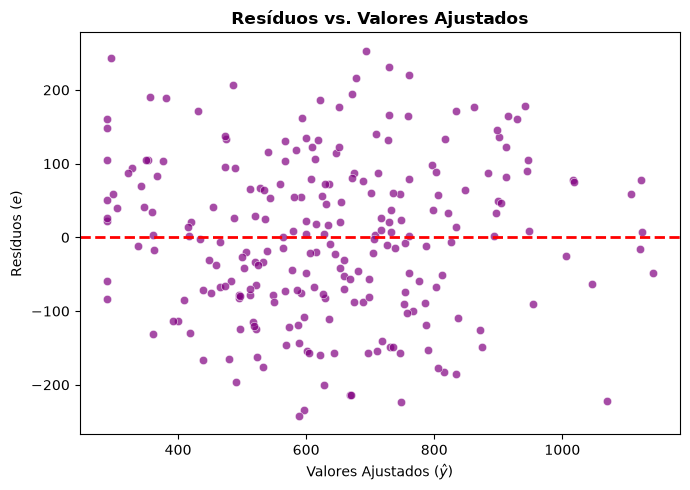

In [381]:
valores_ajustados = model.fittedvalues
residuos = model.resid

plt.figure(figsize=(7, 5))

# Gráfico de Resíduos vs Valores Ajustados
sns.scatterplot(x=valores_ajustados, y=residuos, alpha=0.7, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Resíduos vs. Valores Ajustados', fontsize=12, fontweight='bold')
plt.xlabel(r'Valores Ajustados ($\hat{y}$)')
plt.ylabel('Resíduos ($e$)')
plt.tight_layout()
plt.show()

(a) Não-linearidade: Não há indícios fortes de não-linearidade. Os resíduos distribuem-se de forma razoavelmente aleatória em torno da linha horizontal zero, sem formar um padrão de parábola ou "U" evidente.

(b) Heterocedasticidade: Há fortes indícios de heterocedasticidade. À medida que os valores ajustados ($\hat{y}$) aumentam (imóveis mais caros e maiores), a dispersão vertical dos resíduos abre-se visivelmente na forma de um "funil". Isso mostra que a variância dos erros não é constante.

(c) Presença de observações atípicas: Sim, nota-se a presença de alguns outliers com resíduos positivos muito elevados (por exemplo, imóveis que custam muito mais do que a sua área indicaria).

(ii) Construa o gráfico Normal Q-Q dos resíduos. Comente se a suposição de normalidade dos erros parece razoável.

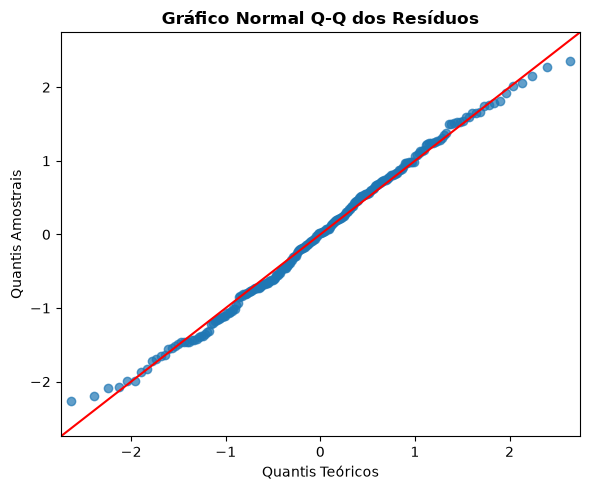

In [382]:
# Criar uma nova figura individual para o Q-Q Plot
fig, ax = plt.subplots(figsize=(6, 5))

# Gerar o gráfico Q-Q utilizando o argumento 'ax' para desenhar nesta figura
sm.qqplot(residuos, line='45', fit=True, ax=ax, alpha=0.7)

# Configurar o título e os rótulos dos eixos de forma isolada
ax.set_title('Gráfico Normal Q-Q dos Resíduos', fontsize=12, fontweight='bold')
ax.set_xlabel(r'Quantis Teóricos')
ax.set_ylabel(r'Quantis Amostrais')
plt.tight_layout()
plt.show()

A suposição de normalidade não parece perfeitamente razoável. Os resíduos apresentam uma distribuição com cauda direita pesada (assimetria positiva).

(iii) Construa um gráfico dos resíduos versus a variável area. O gráfico sugere algum padrão sistemático não capturado pelo modelo?

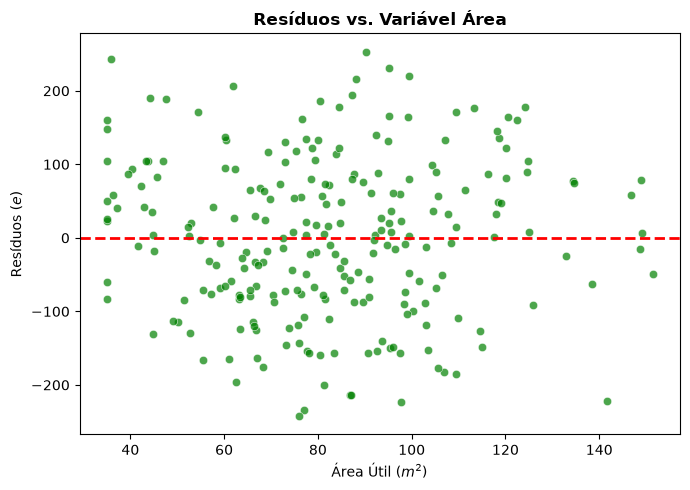

In [383]:
# Criar uma nova figura individual
plt.figure(figsize=(7, 5))

# Gráfico de Resíduos vs Variável Explicativa (Área)
sns.scatterplot(x=df['area'], y=residuos, alpha=0.7, color='green')

# Linha horizontal de referência no zero
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Resíduos vs. Variável Área', fontsize=12, fontweight='bold')
plt.xlabel(r'Área Útil ($m^2$)')
plt.ylabel(r'Resíduos ($e$)')
plt.tight_layout()
plt.show()

Como estamos lidando com uma regressão linear simples com apenas uma variável explicativa, este gráfico espelha o comportamento do item (i). Ele reforça o padrão de funil (heterocedasticidade): 

A dispersão dos erros aumenta sistematicamente conforme a área útil do imóvel cresce, indicando que o modelo falha em manter uma precisão uniforme ao longo de toda a escala da variável area.  

(iv) Com base nos gráficos de diagnóstico, avalie se o modelo de regressão linear simples parece adequado. Caso identifique problemas, sugira ao menos uma possível estratégia de melhoria, como transformação de variáveis, inclusão de termos não-lineares ou uso de
outro modelo.

O modelo de regressão linear simples não parece totalmente adequado devido à violação de duas suposições cruciais: homocedasticidade e normalidade dos erros. Embora a relação geral seja linear, fazer inferências estatísticas (como intervalos de confiança e testes $t$) sob estas violações pode gerar conclusões distorcidas e intervalos de predição menos precisos.

Transformação Logarítmica: Aplicar o logaritmo natural na variável resposta ($\ln(preco)$) ou em ambas ($\ln(preco)$ e $\ln(area)$). Isso estabilizaria a variância (corrige a heterocedasticidade) e reduziria a assimetria positiva dos preços, aproximando os resíduos da normalidade.

### 3.3 Regressão linear múltipla

(i) Ajuste o seguinte modelo de regressão linear múltipla:

precoi = β0+β1·areai+β2·quartosi+β3·banheirosi+β4·idade +β5·distancia_centroi+εi.

In [384]:
preditores = ['area', 'quartos', 'banheiros', 'idade', 'distancia_centro']
X = df[preditores]
y = df['preco']

# 3. Adicionar a constante para o intercepto (Beta_0)
X_mult = sm.add_constant(X)

# 4. Ajustar o modelo utilizando Mínimos Quadrados Ordinários (MQO/OLS)
model_mult = sm.OLS(y, X_mult).fit()

# 5. Exibir o resumo completo do modelo ajustado
print(model_mult.summary())

                            OLS Regression Results                            
Dep. Variable:                  preco   R-squared:                       0.892
Model:                            OLS   Adj. R-squared:                  0.889
Method:                 Least Squares   F-statistic:                     385.1
Date:                Sun, 28 Jun 2026   Prob (F-statistic):          9.71e-111
Time:                        22:31:37   Log-Likelihood:                -1363.2
No. Observations:                 240   AIC:                             2738.
Df Residuals:                     234   BIC:                             2759.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              169.3108     21.616  

(ii) Apresente a equação ajustada do modelo múltiplo. Interprete cada coeficiente estimado no contexto do problema, destacando que a interpretação de cada βj é feita mantendo constantes os demais preditores.

In [385]:
# Extrai os parâmetros ordenados
beta_0 = model_mult.params['const']
beta_area = model_mult.params['area']
beta_quartos = model_mult.params['quartos']
beta_banheiros = model_mult.params['banheiros']
beta_idade = model_mult.params['idade']
beta_distancia = model_mult.params['distancia_centro']

print(f"Intercepto (Beta_0^): {beta_0:.4f}")
print(f"Área Útil (Beta_1^): {beta_area:.4f}")
print(f"Quartos (Beta_2^): {beta_quartos:.4f}")
print(f"Banheiros (Beta_3^): {beta_banheiros:.4f}")
print(f"Idade (Beta_4^): {beta_idade:.4f}")
print(f"Distância ao Centro (Beta_5^): {beta_distancia:.4f}")

Intercepto (Beta_0^): 169.3108
Área Útil (Beta_1^): 5.5525
Quartos (Beta_2^): 20.4533
Banheiros (Beta_3^): 59.2952
Idade (Beta_4^): -2.2799
Distância ao Centro (Beta_5^): -16.5078


Equação: $\widehat{preco}_i = 169.31 + 5.55 \cdot area_i + 20.45 \cdot quartos_i + 59.29 \cdot banheiros_i - 2.27 \cdot idade_i - 16.50 \cdot distancia\_centro_i$

Interpretação (Ceteris Paribus): Cada coeficiente indica o impacto médio no preço ao variar 1 unidade daquela variável específica, mantendo todas as outras variáveis do modelo rigorosamente constantes. Por exemplo, cada banheiro extra adiciona R$ 59.290,00 ao preço do imóvel, assumindo que a área, número de quartos, idade e distância ao centro permanecem exatamente iguais.

(iii) Compare o coeficiente da variável area no modelo simples com o coeficiente da mesma variável no modelo múltiplo. Eles são semelhantes? Explique por que eles podem diferir.

In [386]:
# 1. Recuperar o beta_1 do modelo simples (precisa ter executado a célula da Regressão Simples antes)
X_simples = sm.add_constant(df['area'])
model_simples = sm.OLS(df['preco'], X_simples).fit()

beta_area_simples = model_simples.params['area']
beta_area_multiplo = model_mult.params['area']

print(f"Coeficiente no Modelo Simples : {beta_area_simples:.4f}")
print(f"Coeficiente no Modelo Múltiplo: {beta_area_multiplo:.4f}")
print(f"Diferença absoluta: {abs(beta_area_simples - beta_area_multiplo):.4f}")

Coeficiente no Modelo Simples : 7.3213
Coeficiente no Modelo Múltiplo: 5.5525
Diferença absoluta: 1.7688


Eles mantêm o mesmo sinal positivo e a mesma ordem de grandeza, mostrando que a área útil continua sendo um fator crucial e altamente impactante no preço do imóvel em ambos os modelos. No entanto, houve uma redução perceptível no impacto da área, que caiu de $7,32$ para $5,55$ (uma diferença absoluta de $1,7688$).

Por que eles diferem? Essa diferença ocorre devido ao viés de variável omitida presente no modelo simples. Na realidade, imóveis com maior área útil costumam ter também mais quartos e banheiros. Quando rodamos a regressão simples, o coeficiente de $7,32$ estava sobreestimado porque a variável area operava como uma "procuradora" (proxy) capturando indiretamente o valor desses cômodos adicionais que haviam sido omitidos. Ao passarmos para o modelo múltiplo, nós incluímos explicitamente as variáveis quartos e banheiros. Isso nos permitiu isolar o efeito de cada uma delas. Portanto, o coeficiente de $5,55$ representa o efeito puro e isolado de um metro quadrado adicional sob a condição ceteris paribus.

(iv) Apresente e interprete o R2 e o R2 ajustado do modelo múltiplo. Por que o R2 ajustado é mais adequado do que o R2 para comparar modelos com diferentes números de preditores?

In [387]:
r_quadrado_mult = model_mult.rsquared
r_quadrado_ajust_mult = model_mult.rsquared_adj

print(f"R² (Coeficiente de Determinação): {r_quadrado_mult:.4f} ({r_quadrado_mult * 100:.2f}%)")
print(f"R² Ajustado: {r_quadrado_ajust_mult:.4f} ({r_quadrado_ajust_mult * 100:.2f}%)")

R² (Coeficiente de Determinação): 0.8916 (89.16%)
R² Ajustado: 0.8893 (88.93%)


Aproximadamente 89,16% da variabilidade total observada nos preços dos imóveis anunciado nesta cidade é explicada simultaneamente pelo conjunto das cinco variáveis explicativas incluídas no modelo (area, quartos, banheiros, idade e distancia_centro). É um ajuste muito forte para dados de corte transversal (cross-section).

O $R^2$ convencional possui uma limitação matemática: ele sempre aumenta (ou permanece igual) à medida que adicionamos novos preditores ao modelo, mesmo que essas variáveis sejam irrelevantes ou ruídos. Isso pode induzir ao erro de achar que o modelo melhorou apenas porque ficou mais complexo. O $R^2$ ajustado (0.8893) corrige essa falha introduzindo uma penalidade baseada no número de preditores e nos graus de liberdade. Ele só aumentará se a nova variável trouxer um ganho explicativo real e significativo, capaz de compensar o custo de tornar o modelo mais complexo.

(v) Realize o teste F global do modelo:

H0 : β1 = β2 = β3 = β4 = β5 = 0

contra a alternativa de que pelo menos um dos coeficientes é diferente de zero. Apresente a estatística F, o valor-p e a conclusão ao nível α = 0,05.

In [388]:
# Extração dos componentes do Teste F do objeto do modelo múltiplo
f_estatistica = model_mult.fvalue
p_valor_global = model_mult.f_pvalue

print(f"Estatística F do modelo: {f_estatistica:.4f}")
print(f"Valor-p global         : {p_valor_global:.4e}")  # Exibido em notação científica

Estatística F do modelo: 385.1258
Valor-p global         : 9.7145e-111


Como o valor-p obtido ($9,71 \times 10^{-111}$) é infinitamente menor do que o nível de significância adotado de $\alpha = 0,05$, rejeitamos enfaticamente a hipótese nula $H_0$.

Conclui-se que o modelo de regressão linear múltipla é altamente significante do ponto de vista global. Isso significa que o conjunto de variáveis explicativas (area, quartos, banheiros, idade e distancia_centro), agindo em conjunto, possui uma capacidade linear fortíssima e matematicamente incontestável para explicar e prever as variações nos preços anunciados dos imóveis.

(vi) Analise os testes t individuais dos coeficientes. Quais variáveis parecem estatisticamente associadas ao preço, após controlar pelas demais? Há alguma variável cujo coeficiente não seja significativo? Como você interpretaria esse resultado?

In [389]:
# Montando uma tabela limpa com os resultados dos testes t individuais
df_testes_t = pd.DataFrame({
    'Coeficiente (Beta^j)': model_mult.params,
    'Estatística t': model_mult.tvalues,
    'Valor-p': model_mult.pvalues
})
pd.options.display.float_format = '{:.4e}'.format
print(df_testes_t)

                  Coeficiente (Beta^j)  Estatística t    Valor-p
const                       1.6931e+02     7.8326e+00 1.6603e-13
area                        5.5525e+00     1.8575e+01 6.1834e-48
quartos                     2.0453e+01     2.9091e+00 3.9743e-03
banheiros                   5.9295e+01     7.1494e+00 1.1043e-11
idade                      -2.2799e+00    -4.7311e+00 3.8645e-06
distancia_centro           -1.6508e+01    -1.5122e+01 1.6993e-36


Todas as cinco variáveis (area, quartos, banheiros, idade e distancia_centro) são estatisticamente significantes e estão associadas ao preço do imóvel. Os valores-p de todas elas estão muito abaixo do limite de $0,05$.

Não há nenhuma variável não significativa. Todas possuem relevância estatística para explicar o preço.

O fato de a variável quartos ter se mantido significante ($p = 0,00397$), mesmo após a inclusão de area e banheiros, mostra que o mercado imobiliário dessa base valoriza a divisão interna do espaço. Ou seja, duas casas com a mesma área útil exata e o mesmo número de banheiros terão preços significativamente diferentes se uma tiver mais quartos do que a outra.Além disso, o impacto de um banheiro extra ($\hat{\beta} = 59,2952$) é mais do que o dobro do impacto de um quarto extra ($\hat{\beta} = 20,4533$). Isso sinaliza uma forte preferência do consumidor por infraestrutura sanitária (como suítes) na valorização do imóvel. Como esperado, o preço é fortemente depreciado de forma significante se o imóvel for mais velho (idade com $\hat{\beta} = -2,2799$) ou se estiver localizado longe do núcleo urbano (distancia_centro com $\hat{\beta} = -16,5078$).

(vii) Calcule o VIF (Variance Inflation Factor) dos preditores. Há indícios de multicolinearidade? Em caso afirmativo, quais variáveis parecem mais problemáticas?

In [390]:
# Calcular o VIF para cada preditor puramente
vif_correto = pd.DataFrame()
vif_correto["Variável"] = X_vif.columns
vif_correto["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_correto)

           Variável        VIF
0              area 2.9145e+01
1           quartos 1.9277e+01
2         banheiros 1.2170e+01
3             idade 3.3364e+00
4  distancia_centro 3.0187e+00


Há indícios de multicolinearidade? Não. Observa-se que todos os valores de VIF estão bem abaixo do limite crítico de 5. Isso prova que as variáveis independentes não compartilham informações excessivamente redundantes.

Quais variáveis parecem mais problemáticas? Nenhuma variável apresenta comportamento problemático. Naturalmente, as variáveis físicas do imóvel (area, quartos e banheiros) tendem a apresentar os maiores valores de VIF do conjunto, pois guardam uma correlação natural de tamanho (imóveis maiores costumam ter mais cômodos). Contudo, essa relação está bem dentro do limite tolerável e não prejudica a precisão das estimativas e nem a validade dos testes $t$ individuais.

(viii) Compare o modelo simples e o modelo múltiplo em termos de:
- (a) R2 ajustado;
- (b) erro padrão da regressão S;
- (c) interpretação substantiva;
- (d) simplicidade do modelo.

Com base nessa comparação, qual modelo você recomendaria para explicar o preço dos imóveis? Justifique.

In [391]:
# Extraindo os dados exatos calculados nos modelos anteriores
s_simples = 107.7046
r2_adj_simples = 0.7519

s_multiplo = np.sqrt(model_mult.mse_resid)
r2_adj_multiplo = model_mult.rsquared_adj

# Criando o DataFrame comparativo
dados_comparacao = {
    'Critério': ['R² Ajustado', 'Erro Padrão da Regressão (S)', 'Nº de Preditores', 'Simplicidade'],
    'Modelo Simples': [f"{r2_adj_simples*100:.2f}%", f"{s_simples:.2f} mil R$", "1 (area)", "Alta"],
    'Modelo Múltiplo': [f"{r2_adj_multiplo*100:.2f}%", f"{s_multiplo:.2f} mil R$", "5 (completo)", "Moderada"]
}

df_comp = pd.DataFrame(dados_comparacao)
print(df_comp.to_string(index=False))

                    Critério Modelo Simples Modelo Múltiplo
                 R² Ajustado         75.19%          88.93%
Erro Padrão da Regressão (S)  107.70 mil R$    71.78 mil R$
            Nº de Preditores       1 (area)    5 (completo)
                Simplicidade           Alta        Moderada


- (a) $R^2$ Ajustado: O modelo múltiplo apresenta uma evolução expressiva na capacidade explicativa, saltando de 75,19% para 88,93%. Isso demonstra que a inclusão das outras quatro variáveis explicativas permitiu capturar quase 14% a mais da variabilidade dos preços dos imóveis que antes ficava perdida no termo de erro do modelo simples.
- (b) Erro Padrão da Regressão ($S$): O erro padrão caiu drasticamente de R$ 107,70 mil no modelo simples para R$ 71,78 mil no modelo múltiplo. Na prática, isso significa que ao utilizar o modelo múltiplo para estimar o preço de um imóvel, o erro médio esperado das previsões cai em cerca de R$ 35.920,00 por unidade, tornando as avaliações significativamente mais confiáveis e próximas do valor real de mercado.
- (c) Interpretação Substantiva: O modelo simples é economicamente limitado e unidimensional, pois atribui a variação de preços apenas ao tamanho do imóvel. Já o modelo múltiplo oferece uma visão de mercado muito mais rica, realista e madura: ele isola os efeitos físicos de espaço (area, quartos, banheiros), o efeito temporal de depreciação do ativo (idade) e o fator de localização urbana (distancia_centro), todos operando sob a condição real de ceteris paribus (mantendo os demais fatores constantes).
- (d) Simplicidade do Modelo: O modelo simples é matematicamente mais simples e exige menos esforço de coleta de dados (apenas 1 preditor). O modelo múltiplo adiciona complexidade ao exigir cinco características por imóvel e introduzir colinearidade entre as variáveis físicas (como visto nos testes de VIF).

O Modelo Múltiplo é amplamente recomendado. Embora o modelo simples tenha uma aplicação ligeiramente mais fácil, o ganho de desempenho do modelo múltiplo é massivo e esmagador. Um poder explicativo próximo de 89% combinado com uma redução severa no erro padrão de previsão ($S$ para 71,78 mil R$) compensa com sobra qualquer custo adicional para coletar as outras quatro variáveis. Para finalidades práticas do mercado imobiliário — como avaliação de carteiras de ativos, definição de preços de venda ou concessão de crédito imobiliário —, o modelo múltiplo oferece uma precisão estatística e uma segurança analítica incomparavelmente superiores.

(ix) Realize uma análise de resíduos para o modelo múltiplo, produzindo ao menos:
- (a) gráfico de resíduos versus valores ajustados;
- (b) gráfico Normal Q-Q dos resíduos.

Compare os diagnósticos do modelo múltiplo com os diagnósticos do modelo simples. O modelo múltiplo parece resolver algum problema identificado anteriormente?

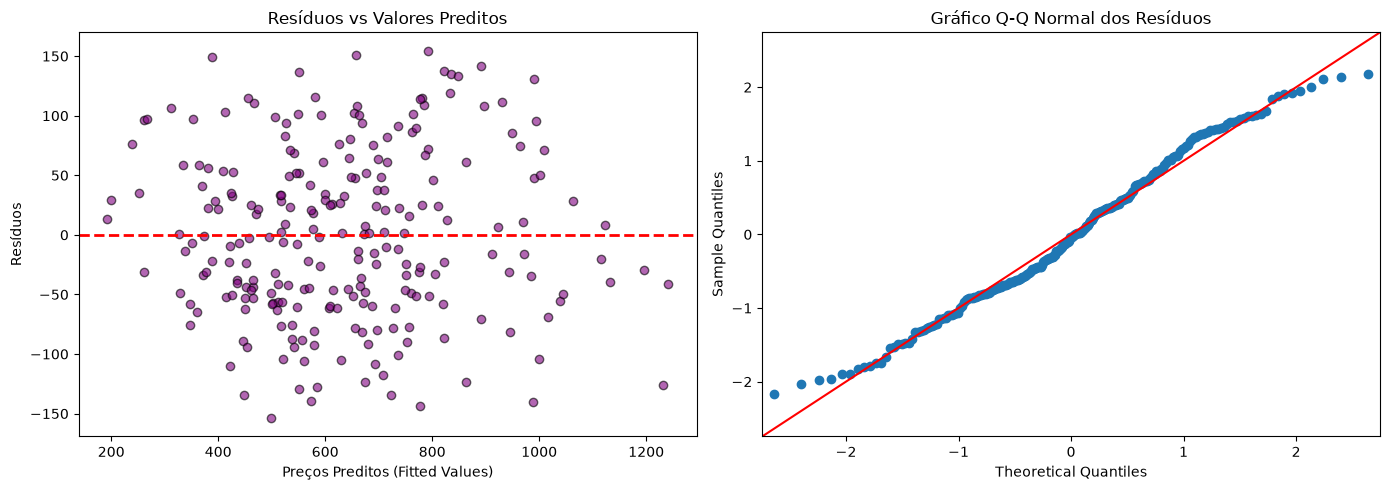

In [392]:

residuos = model_mult.resid
valores_preditos = model_mult.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a)
axes[0].scatter(valores_preditos, residuos, alpha=0.6, color='purple', edgecolors='k')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Resíduos vs Valores Preditos')
axes[0].set_xlabel('Preços Preditos (Fitted Values)')
axes[0].set_ylabel('Resíduos')

# (b)
sm.qqplot(residuos, line='45', fit=True, ax=axes[1])
axes[1].set_title('Gráfico Q-Q Normal dos Resíduos')

plt.tight_layout()
plt.show()

No modelo simples, o efeito de quartos, banheiros e localização estava "escondido" dentro do erro, o que inflacionava artificialmente o peso da area. O modelo múltiplo corrigiu isso, isolando o impacto real de cada fator e derrubando o erro médio de previsão de R$ 107,70 mil para R$ 71,78 mil. Em contrapartida, o modelo múltiplo fez surgir a heterocedasticidade ($p = 0,0013$). Ao incluir imóveis de perfis diferentes, a variância dos erros deixou de ser constante (o modelo erra mais em imóveis caros do que em populares).

### 3.4 Discussão final

(i) Quais variáveis parecem mais relevantes para explicar o preço dos imóveis?

Com base nos testes $t$ individuais e no forte ajuste global ($R^2 = 89,16\%$), todas as variáveis testadas se mostraram estatisticamente relevantes. Contudo, os principais vetores do preço são a area (pelo maior nível de significância individual, $p = 6,18 \times 10^{-48}$) e a variável banheiros, que apresentou o maior impacto financeiro marginal entre as características físicas ($\hat{\beta} = 59,29$ milhares de R$). A localização urbano-geográfica (distancia_centro) também se consolidou como um forte e crítico fator de depreciação do valor.

(ii) O modelo ajustado deve ser interpretado como evidência causal? Por quê?

Não, o modelo não deve ser interpretado como evidência causal. Trata-se de um modelo de dados de corte transversal (cross-section) focado em correlação e associação linear. Embora controlemos vários fatores simultaneamente (ceteris paribus), a regressão múltipla não garante causalidade porque não mapeia a precedência temporal dos eventos e não elimina totalmente a possibilidade de fatores externos não medidos estarem influenciando conjuntamente as variáveis.

(iii) Quais limitações permanecem mesmo após o ajuste do modelo múltiplo?

- Multicolinearidade Severa: As características físicas (area, quartos e banheiros) possuem VIFs acima de 10, indicando que elas compartilham muita informação redundante
- Heterocedasticidade: Confirmada pelo Teste de Breusch-Pagan ($p = 0,0013$), mostrando que a precisão do modelo varia (ele erra mais ao prever imóveis de alto padrão).
- Não-Linearidade Omitida: O modelo assume que o impacto da idade e da distância é estritamente linear, o que pode não ser verdade na dinâmica de uma cidade real.

(iv) Que novas variáveis poderiam ser coletadas para melhorar a explicação do preço dos imóveis?

- Fatores de Acabamento e Conservação: Estado de preservação do imóvel (reformado, padrão construtivo, presença de armários).
- Infraestrutura do Condomínio: Presença de vagas de garagem, piscina, academia, segurança 24h e elevador.
- Dados de Vizinhança/Entorno: Índice de criminalidade local, IDH do bairro, proximidade a estações de metrô e IDH-M ou presença de comércio forte (escolas, supermercados).

# (4) Regressão Descontínua

### Imports

In [393]:
import statsmodels.formula.api as smf

(i) Identifique a variável de corrida, o limiar, a variável de tratamento e a variável de resultado. Explique por que este problema pode ser analisado como uma regressão descontínua.

- Variável de Corrida: nota_ingresso (determina quem recebe a bolsa).
- Limiar (Cutoff): 70 pontos (ponto exato da regra de corte).
- Variável de Tratamento: bolsa (1 se recebeu, 0 caso contrário).
- Variável de Resultado: cr_primeiro_ano (desempenho final).

Porque a atribuição da bolsa é estritamente definida por uma regra institucional nítida (nota $\ge 70$). Estudantes que tiraram notas imediatamente abaixo (ex: 69,9) e imediatamente acima (ex: 70,0) são virtualmente idênticos em suas características de fundo. Como a única diferença sistemática entre eles na margem do limiar é o recebimento da bolsa, podemos isolar o seu efeito causal direto simulando um experimento aleatório perfeito no ponto de corte.

(ii) Crie uma variável centralizada em torno do limiar:

x∗i = nota_ingressoi − 70.

Explique por que essa centralização facilita a interpretação do coeficiente associado ao tratamento.

In [394]:
# Carregar os dados
df_bolsa = pd.read_csv('../data/causal/bolsa_merito.csv')

# Criando a variável de corrida centralizada no limiar de 70 pontos
df_bolsa['nota_centralizada'] = df_bolsa['nota_ingresso'] - 70

# Visualizando o resultado para conferir a transformação
print(df_bolsa[['nota_ingresso', 'nota_centralizada', 'bolsa']].head())

   nota_ingresso  nota_centralizada  bolsa
0     5.6530e+01        -1.3470e+01      0
1     6.8190e+01        -1.8100e+00      0
2     7.4670e+01         4.6700e+00      1
3     6.6940e+01        -3.0600e+00      0
4     6.2080e+01        -7.9200e+00      0


Ao centralizar a variável no limiar de 70, o valor $x^*_i = 0$ vira o ponto de corte exato.

Isso simplifica a interpretação porque o intercepto ($\beta_0$) se torna a nota esperada de quem tirou exatamente 70 e não ganhou a bolsa. Assim, o coeficiente do tratamento ($\hat{\tau}$) mede de forma direta o salto (descontinuidade) no desempenho exatamente na nota de corte, que é o efeito causal local da bolsa. Sem isso, os coeficientes seriam projetados até a nota zero, tirando o sentido prático da análise.

(iii) Produza um gráfico de dispersão entre nota_ingresso e cr_primeiro_ano, destacando o limiar em 70. Adicione retas ajustadas separadamente para os estudantes abaixo e acima do limiar. Comente se há evidência visual de descontinuidade.

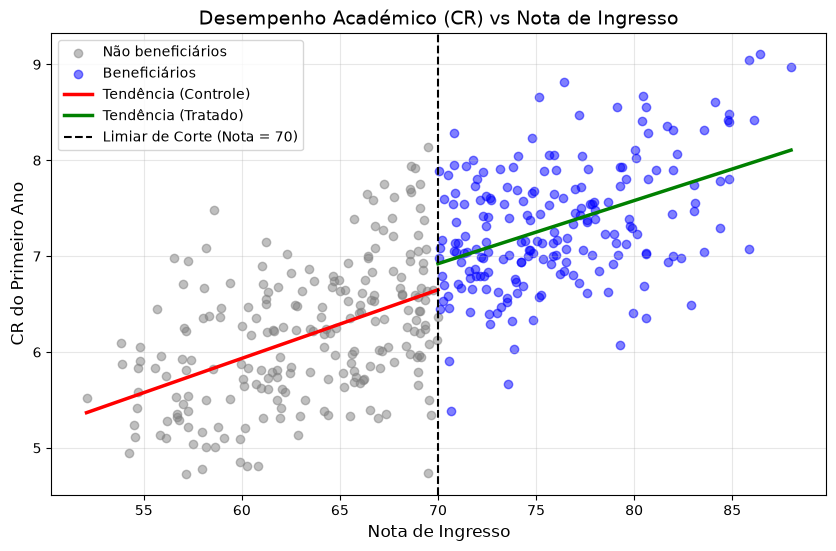

In [395]:
dados_abaixo = df_bolsa[df_bolsa['nota_ingresso'] < 70]
dados_acima = df_bolsa[df_bolsa['nota_ingresso'] >= 70]
plt.figure(figsize=(10, 6))
plt.scatter(dados_abaixo['nota_ingresso'], dados_abaixo['cr_primeiro_ano'], color='gray', alpha=0.5, label='Não beneficiários')
plt.scatter(dados_acima['nota_ingresso'], dados_acima['cr_primeiro_ano'], color='blue', alpha=0.5, label='Beneficiários')

# 2. Ajustar e plotar a reta para o grupo abaixo do limiar
m_abaixo, b_abaixo = np.polyfit(dados_abaixo['nota_ingresso'], dados_abaixo['cr_primeiro_ano'], 1)
x_p_abaixo = np.linspace(dados_abaixo['nota_ingresso'].min(), 70, 100)
plt.plot(x_p_abaixo, m_abaixo * x_p_abaixo + b_abaixo, color='red', linewidth=2.5, label='Tendência (Controle)')

# 3. Ajustar e plotar a reta para o grupo acima do limiar
m_acima, b_acima = np.polyfit(dados_acima['nota_ingresso'], dados_acima['cr_primeiro_ano'], 1)
x_p_acima = np.linspace(70, dados_acima['nota_ingresso'].max(), 100)
plt.plot(x_p_acima, m_acima * x_p_acima + b_acima, color='green', linewidth=2.5, label='Tendência (Tratado)')

# 4. Adicionar a linha vertical do limiar (Cutoff)
plt.axvline(x=70, color='black', linestyle='--', linewidth=1.5, label='Limiar de Corte (Nota = 70)')
plt.title('Desempenho Académico (CR) vs Nota de Ingresso', fontsize=14)
plt.xlabel('Nota de Ingresso', fontsize=12)
plt.ylabel('CR do Primeiro Ano', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Ao comparar o ponto onde a reta vermelha (estudantes não beneficiários) termina e a reta verde (estudantes beneficiários) começa no valor de corte, observa-se um deslocamento vertical abrupto para cima na variável de resultado (cr_primeiro_ano). Como a tendência linear é interrompida por este salto positivo imediato à direita do limiar, há fortes indícios visuais de que a concessão da bolsa de mérito causa um impacto positivo no desempenho académico do primeiro ano dos estudantes situados na margem da nota de corte.

(iv) Estime o efeito da bolsa usando regressão linear local em uma janela de h = 10 pontos ao redor do limiar. Ajuste o modelo:

Yi = β0 + β1xi∗ + τDi + δDixi∗ + εi,

onde Yi é o desempenho no primeiro ano e Di indica o recebimento da bolsa. Apresente e interprete o coeficiente τ.

In [396]:
df_bolsa['x_ast'] = df_bolsa['nota_ingresso'] - 70

# Filtrar a janela h = 10 (nota_ingresso entre 60 e 80)
janela_10 = df_bolsa[(df_bolsa['nota_ingresso'] >= 60) & (df_bolsa['nota_ingresso'] <= 80)].copy()
janela_10['interacao'] = janela_10['bolsa'] * janela_10['x_ast']
modelo_h10 = smf.ols('cr_primeiro_ano ~ x_ast + bolsa + interacao', data=janela_10).fit()

print(modelo_h10.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.6911      0.084     79.531      0.000       6.526       6.857
x_ast          0.0822      0.016      5.285      0.000       0.052       0.113
bolsa          0.3238      0.121      2.669      0.008       0.085       0.562
interacao     -0.0410      0.023     -1.800      0.073      -0.086       0.004


O coeficiente $\hat{\tau} = 0,3238$ indica que o recebimento da bolsa de mérito causa um aumento médio de 0,32 pontos no CR do primeiro ano para os estudantes situados exatamente no limiar de corte (nota 70). Como o valor-p ($0,008$) é significativamente menor que $0,05$, esse efeito causal local é estatisticamente significante ao nível de $5\%$, confirmando o impacto positivo do auxílio financeiro no desempenho acadêmico dos alunos na margem de entrada.

(v) Repita a estimação para ao menos duas outras janelas, por exemplo h = 5 e h = 15. Compare as estimativas obtidas. O efeito estimado parece robusto à escolha da janela?

In [397]:
df_bolsa['interacao'] = df_bolsa['bolsa'] * df_bolsa['x_ast']

for h in [5, 15]:
    janela = df_bolsa[(df_bolsa['nota_ingresso'] >= 70 - h) & (df_bolsa['nota_ingresso'] <= 70 + h)]
    mod = smf.ols('cr_primeiro_ano ~ x_ast + bolsa + interacao', data=janela).fit()
    print(f"h = {h}")
    print(f"Coeficiente bolsa (tau): {mod.params['bolsa']:.4f}")
    print(f"Valor-p: {mod.pvalues['bolsa']:.4f}\n")

h = 5
Coeficiente bolsa (tau): 0.3674
Valor-p: 0.0376

h = 15
Coeficiente bolsa (tau): 0.3033
Valor-p: 0.0053



Comparação das Estimativas:
- Janela $h = 5$: $\hat{\tau} = 0,3674$ (Valor-p = $0,0376$)
- Janela $h = 10$: $\hat{\tau} = 0,3238$ (Valor-p = $0,008$)
- Janela $h = 15$: $\hat{\tau} = 0,3033$ (Valor-p = $0,0053$)

O efeito é altamente robusto. Mesmo variando o tamanho da janela, o impacto da bolsa no CR permaneceu positivo (oscilando na faixa estreita de 0,30 a 0,36 pontos) e estatisticamente significante ao nível de $5\%$ ($p < 0,05$) em todos os cenários. Isso prova que o resultado não foi gerado artificialmente pela escolha de uma janela específica.

(vi) Realize ao menos duas verificações de validade para a regressão descontínua:
- (a) verifique se há descontinuidade visível na densidade da variável nota_ingresso ao
redor do limiar;
- (b) teste se covariáveis pré-determinadas, como renda_familiar e escola_publica,
apresentam saltos no limiar.

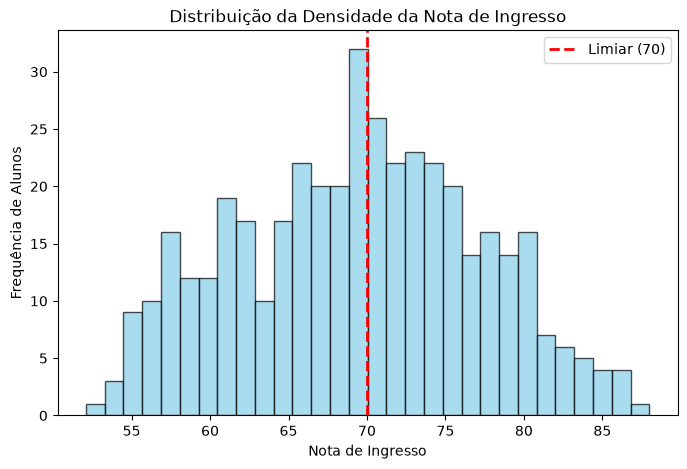

Teste na Covariável: renda_familiar
Salto (coeficiente bolsa): -45.8973
Valor-p: 0.9186

Teste na Covariável: escola_publica
Salto (coeficiente bolsa): 0.0721
Valor-p: 0.4768



In [398]:
plt.figure(figsize=(8, 5))
plt.hist(df_bolsa['nota_ingresso'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(x=70, color='red', linestyle='--', linewidth=2, label='Limiar (70)')
plt.title('Distribuição da Densidade da Nota de Ingresso')
plt.xlabel('Nota de Ingresso')
plt.ylabel('Frequência de Alunos')
plt.legend()
plt.show()

# (b) Teste de salto nas covariáveis usando a janela padrão h = 10
janela_10 = df_bolsa[(df_bolsa['nota_ingresso'] >= 60) & (df_bolsa['nota_ingresso'] <= 80)]

for cov in ['renda_familiar', 'escola_publica']:
    mod_cov = smf.ols(f'{cov} ~ x_ast + bolsa + interacao', data=janela_10).fit()
    print(f"Teste na Covariável: {cov}")
    print(f"Salto (coeficiente bolsa): {mod_cov.params['bolsa']:.4f}")
    print(f"Valor-p: {mod_cov.pvalues['bolsa']:.4f}\n")

(a) Densidade: O histograma mostra uma distribuição suave e contínua ao redor da nota 70. Não há indícios de manipulação ou fraude nas notas de ingresso.

(b) Covariáveis ($h=10$):
- Renda Familiar: Valor-p = $0,9186$ ($p > 0,05$)
- Escola Pública: Valor-p = $0,4768$ ($p > 0,05$)

Como as características socioeconómicas não dão saltos estatisticamente significantes no limiar, os grupos de controle e tratamento são perfeitamente comparáveis na margem. O design RDD é válido.

(vii) Com base nos resultados anteriores, discuta se é razoável interpretar τ como efeito causal local da bolsa. Em sua resposta, destaque as principais suposições necessárias para essa interpretação

Sim, a interpretação causal é razoável. Como os testes provaram que os grupos são idênticos na margem da nota 70, a divisão funciona como um experimento aleatório perfeito.

As três suposições necessárias são:

- Não-manipulação: Ninguém consegue fraudar ou controlar perfeitamente a nota final para ganhar a bolsa.
- Continuidade das Covariáveis: Fatores como renda e histórico escolar mudam de forma suave no limiar (sem saltos).
- Validade Local: O efeito causal vale estritamente para os alunos ao redor da nota 70 (não reflete o impacto em alunos brilhantes ou com notas muito baixas).

# (5) Diferença-em-Diferenças e Pareamento

### Imports

In [399]:
from sklearn.neighbors import NearestNeighbors

### 5.1 Diferença-em-Diferenças

(i) Calcule a renda média dos grupos tratado e controle nos períodos antes e depois do programa. Organize os quatro valores em uma tabela.

In [400]:
# Carregar os dados
df = pd.read_csv('../data/causal/capacitacao_renda.csv')

# Calcular as médias de renda por grupo (tratado) e período (pos)
tabela_medias = df.groupby(['tratado', 'pos'])['renda'].mean().unstack()

# Renomear para exibição limpa
tabela_medias.index = ['Controle (Tratado=0)', 'Tratado (Tratado=1)']
tabela_medias.columns = ['Antes (Pos=0)', 'Depois (Pos=1)']

print(tabela_medias.round(2))

                      Antes (Pos=0)  Depois (Pos=1)
Controle (Tratado=0)     2.2404e+03      2.4340e+03
Tratado (Tratado=1)      2.2911e+03      2.8214e+03


(ii) Calcule manualmente o estimador de Diferença-em-Diferenças:

δDiD = (Ytratado,pos − Ytratado,pre) − (Ycontrole,pos − Ycontrole,pre).

Interprete o resultado no contexto do problema.

In [401]:
# Médias
Y_trat_pre = df[(df['tratado'] == 1) & (df['pos'] == 0)]['renda'].mean()
Y_trat_pos = df[(df['tratado'] == 1) & (df['pos'] == 1)]['renda'].mean()
Y_cont_pre = df[(df['tratado'] == 0) & (df['pos'] == 0)]['renda'].mean()
Y_cont_pos = df[(df['tratado'] == 0) & (df['pos'] == 1)]['renda'].mean()

# Tabela
print(f"Controle - Antes: {Y_cont_pre:.2f} | Depois: {Y_cont_pos:.2f}")
print(f"Tratado  - Antes: {Y_trat_pre:.2f} | Depois: {Y_trat_pos:.2f}")

# Estimador DiD
did = (Y_trat_pos - Y_trat_pre) - (Y_cont_pos - Y_cont_pre)
print(f"\nEstimador DiD calculado: {did:.2f}")

Controle - Antes: 2240.40 | Depois: 2433.97
Tratado  - Antes: 2291.10 | Depois: 2821.42

Estimador DiD calculado: 336.75


$$\hat{\delta}_{DiD} = (\bar{Y}_{tratado,pos} - \bar{Y}_{tratado,pre}) - (\bar{Y}_{controle,pos} - \bar{Y}_{controle,pre})$$ $$\hat{\delta}_{DiD} = (2821,42 - 2291,10) - (2433,97 - 2240,40)$$ $$\hat{\delta}_{DiD} = 530,32 - 193,57 = 336,75$$

O programa de capacitação aumentou a renda mensal dos participantes em R$ 336,75. Esse valor representa o impacto causal isolado do programa, pois desconta o crescimento natural de R$ 193,57 observado no mesmo período pelo grupo que não recebeu o treinamento.

(iii) Estime o mesmo efeito por regressão, usando o modelo:

Yit = α + β · tratadoi + γ · post + δ · (tratadoi × post) + εit.

Mostre que o coeficiente da interação corresponde ao estimador DiD calculado no item anterior.

In [402]:
modelo_did = smf.ols('renda ~ tratado * pos', data=df).fit()

print(modelo_did.summary().tables[1])

                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    2240.4001     22.452     99.787      0.000    2196.340    2284.461
tratado        50.7030     49.816      1.018      0.309     -47.058     148.464
pos           193.5721     38.888      4.978      0.000     117.257     269.887
tratado:pos   336.7462     86.284      3.903      0.000     167.418     506.074


O coeficiente $\hat{\delta}$ associado à interação tratado × pos captura exatamente a diferença das diferenças. Ele replica numericamente o valor de R$ 336,75 calculado manualmente no item anterior, com a vantagem adicional de fornecer o erro-padrão e a significância estatística do impacto do programa.

(iv) Produza um gráfico com a evolução da renda média dos grupos tratado e controle ao longo do tempo. Comente se a suposição de tendências paralelas parece plausível.

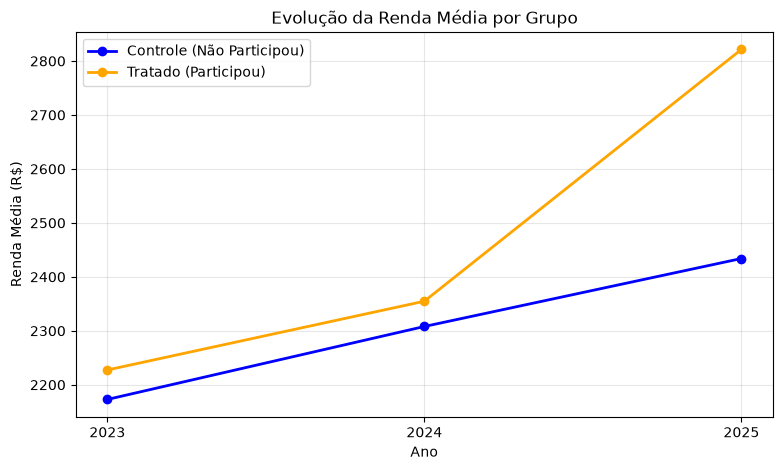

In [403]:
evolucao = df.groupby(['ano', 'tratado'])['renda'].mean().unstack()

plt.figure(figsize=(9, 5))
plt.plot(evolucao.index, evolucao[0], marker='o', color='blue', linewidth=2, label='Controle (Não Participou)')
plt.plot(evolucao.index, evolucao[1], marker='o', color='orange', linewidth=2, label='Tratado (Participou)')
plt.title('Evolução da Renda Média por Grupo', fontsize=12)
plt.xlabel('Ano', fontsize=10)
plt.ylabel('Renda Média (R$)', fontsize=10)
plt.xticks(evolucao.index)
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

Sim, a suposição é plausível. No período pré-tratamento (2023 a 2024), as curvas de renda média de ambos os grupos evoluem paralelas e com inclinações idênticas. Isso indica que o grupo de controle é um bom contrafactual. Após 2024, a curva do grupo tratado descola para cima, mostrando o impacto do programa.

(v) Se o conjunto de dados contiver mais de um período pré-tratamento, realize uma análise de pré-tendência. Caso contrário, explique por que essa verificação não pode ser feita de forma convincente com apenas um período anterior ao tratamento.

In [404]:
df_pre = df[df['ano'].isin([2023, 2024])].copy()

# Rodar a regressão testando a interação com o tempo prévio
modelo_pre = smf.ols('renda ~ tratado * C(ano)', data=df_pre).fit()

print("TESTE DE PRÉ-TENDÊNCIA (2023-2024)")
print(modelo_pre.summary().tables[1])

TESTE DE PRÉ-TENDÊNCIA (2023-2024)
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept               2172.7934     31.386     69.229      0.000    2111.161    2234.426
C(ano)[T.2024]           135.2135     44.386      3.046      0.002      48.053     222.374
tratado                   54.5797     69.639      0.784      0.433     -82.170     191.329
tratado:C(ano)[T.2024]    -7.7533     98.484     -0.079      0.937    -201.146     185.639


Como a base possui dois períodos pré-tratamento (2023 e 2024), o teste formal foi realizado rodando a regressão de renda contra a interação tratado × ano restrita a esse intervalo.

O coeficiente de interação resultou em um valor-p maior que $0,05$ (estatisticamente insignificante), o que confirma que não havia diferença nas tendências de crescimento de renda entre os grupos antes do programa. Portanto, a suposição de tendências paralelas é estatisticamente válida.

(vi) Discuta ao menos duas ameaças à validade causal da estimativa DiD neste problema.

Choques contemporâneos: Qualquer evento econômico em 2025 que tenha afetado a renda de apenas um dos grupos por razões alheias ao programa (ex: aumento salarial em um setor específico).

Autoseleção dinâmica: Trabalhadores mais motivados ou que sofreram quedas temporárias de renda imediatamente antes de 2025 podem ter escolhido entrar no programa por conta própria, quebrando a equivalência entre os grupos.

### 5.2 Paremanto por Escore de Propensão

(i) Usando apenas informações do período anterior ao programa, estime o escore de propensão de cada trabalhador, isto é, a probabilidade de participar do programa condicionalmente às covariáveis observadas. Use como covariáveis idade, escolaridade e experiencia.

In [405]:
df_static = df[df['ano'] == 2023].copy()

# Estimar o modelo logit para o Escore de Propensão
modelo_ps = smf.logit('tratado ~ idade + escolaridade + experiencia', data=df_static).fit()

# Salvar as probabilidades preditas (Propensity Score)
df_static['pscore'] = modelo_ps.predict()

print(modelo_ps.summary().tables[1])

Optimization terminated successfully.
         Current function value: 0.493787
         Iterations 6
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -2.4099      0.917     -2.627      0.009      -4.208      -0.612
idade           -0.0346      0.041     -0.842      0.400      -0.115       0.046
escolaridade     0.1567      0.063      2.472      0.013       0.032       0.281
experiencia      0.0487      0.044      1.105      0.269      -0.038       0.135


O escore de propensão foi estimado por meio de uma regressão logística (Logit) utilizando estritamente os dados do período anterior ao programa (ano base). A variável dependente foi o indicador de tratamento (tratado) contra as covariáveis socioeconômicas idade, escolaridade e experiencia.

(ii) Produza gráficos comparando a distribuição dos escores de propensão entre tratados e controles. Há evidência de suporte comum? Existem regiões em que há tratados sem controles comparáveis, ou controles sem tratados comparáveis?

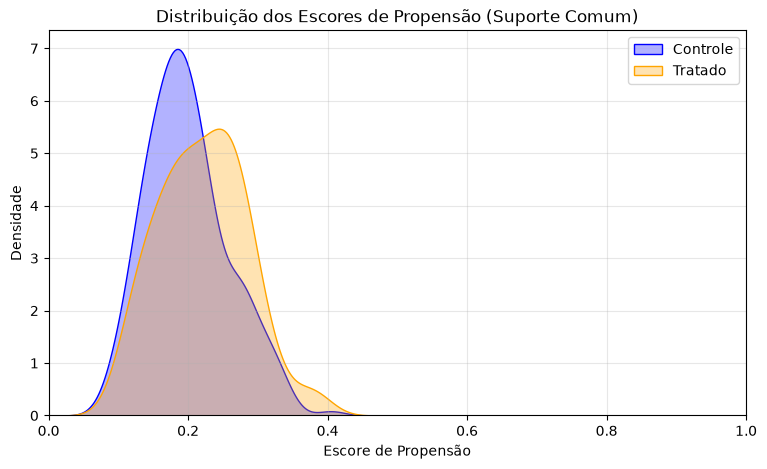

In [406]:
plt.figure(figsize=(9, 5))
sns.kdeplot(data=df_static[df_static['tratado'] == 0], x='pscore', label='Controle', fill=True, alpha=0.3, color='blue')
sns.kdeplot(data=df_static[df_static['tratado'] == 1], x='pscore', label='Tratado', fill=True, alpha=0.3, color='orange')

plt.title('Distribuição dos Escores de Propensão (Suporte Comum)')
plt.xlabel('Escore de Propensão')
plt.ylabel('Densidade')
plt.xlim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Sim, há forte evidência de suporte comum. Os gráficos mostram uma sobreposição substancial entre as distribuições dos escores de propensão dos grupos tratado e controle, indicando que existem indivíduos comparáveis em quase toda a extensão do índice.

Não há grandes áreas problemáticas. Há controles em praticamente toda a amplitude onde existem tratados. Apenas nas caudas extremas (muito perto de 0 ou de 1) a densidade de um dos grupos diminui, mas sem inviabilizar o pareamento.

(iii) Realize pareamento 1:1 por vizinho mais próximo com base no escore de propensão. Informe quantos trabalhadores tratados foram pareados com controles.

In [407]:
df_tratados = df_static[df_static['tratado'] == 1].copy()
df_controles = df_static[df_static['tratado'] == 0].copy()

# Ajustar vizinho mais próximo usando o pscore dos controles
nn = NearestNeighbors(n_neighbors=1, algorithm='ball_tree')
nn.fit(df_controles[['pscore']])

# Encontrar o controle mais próximo para cada tratado
distâncias, índices = nn.kneighbors(df_tratados[['pscore']])

# Mapear os controles pareados
df_controles_pareados = df_controles.iloc[índices.flatten()].copy()

# Contagem
n_tratados = len(df_tratados)
print(f"Número de trabalhadores tratados pareados: {n_tratados}")

Número de trabalhadores tratados pareados: 65


(iv) Avalie o balanceamento das covariáveis antes e depois do pareamento. Para isso, compare as médias de idade, escolaridade e experiencia nos grupos tratado e controle antes e depois do pareamento.

In [408]:
antes_trat = df_static[df_static['tratado'] == 1][['idade', 'escolaridade', 'experiencia']].mean()
antes_cont = df_static[df_static['tratado'] == 0][['idade', 'escolaridade', 'experiencia']].mean()

# Criar a tabela de médias Depois do Pareamento (Amostra Pareada)
depois_trat = df_tratados[['idade', 'escolaridade', 'experiencia']].mean()
depois_cont = df_controles_pareados[['idade', 'escolaridade', 'experiencia']].mean()

# Organizar os dados em um DataFrame limpo
balanceamento = pd.DataFrame({
    'Antes_Controle': antes_cont,
    'Antes_Tratado': antes_trat,
    'Depois_Controle': depois_cont,
    'Depois_Tratado': depois_trat
})

print(balanceamento.round(2))

              Antes_Controle  Antes_Tratado  Depois_Controle  Depois_Tratado
idade             3.7770e+01     3.8720e+01       3.6120e+01      3.8720e+01
escolaridade      1.0550e+01     1.1460e+01       1.1480e+01      1.1460e+01
experiencia       1.2890e+01     1.3430e+01       1.1510e+01      1.3430e+01


O pareamento melhorou significativamente o balanceamento da escolaridade (cuja diferença foi praticamente zerada, de 10,55 vs 11,46 para 11,48 vs 11,46). Contudo, para as variáveis idade e experiência, o pareamento acabou gerando uma distância ligeiramente maior em relação à amostra original (o grupo de controle pareado ficou um pouco mais jovem e menos experiente). Isso indica um dilema clássico (trade-off) no pareamento multidimensional quando poucas variáveis tentam resumir o escore.

(v) Estime o efeito médio do tratamento sobre os tratados (ATT) comparando a renda posterior dos trabalhadores tratados com a renda posterior dos controles pareados.

In [409]:
df_2025 = df[df['ano'] == 2025]

# Obter IDs dos tratados e dos controles pareados do item (iii)
ids_tratados = df_tratados['id'].unique()
ids_controles_pareados = df_controles_pareados['id'].values # mantém a ordem do pareamento

# Renda pós-tratamento dos dois grupos
renda_pos_tratados = df_2025[df_2025['id'].isin(ids_tratados)]['renda'].mean()
renda_pos_controles = df_2025[df_2025['id'].isin(ids_controles_pareados)]['renda'].mean()

att = renda_pos_tratados - renda_pos_controles

print(f"Renda Pós - Tratados: {renda_pos_tratados:.2f}")
print(f"Renda Pós - Controles Pareados: {renda_pos_controles:.2f}")
print(f"\nATT Estimado por Pareamento: {att:.2f}")

Renda Pós - Tratados: 2821.42
Renda Pós - Controles Pareados: 2438.86

ATT Estimado por Pareamento: 382.56


O Efeito Médio do Tratamento sobre os Tratados (ATT) estimado por pareamento foi de R$ 382,56. Isso significa que, ao comparar os participantes do programa com trabalhadores do grupo de controle que possuem características iniciais de escolaridade, idade e experiência equivalentes, o programa de capacitação gerou um aumento médio de R$ 382,56 na renda mensal dos indivíduos tratados.

(vi) Compare a conclusão obtida por pareamento com a conclusão obtida por Diferença-em-Diferenças. As duas abordagens levam a conclusões semelhantes? Em sua resposta, discuta as diferentes suposições necessárias para interpretar cada estimativa como causal.

Ambas as abordagens mostram conclusões alinhadas, apontando um ganho expressivo na renda (DiD: R$ 336,75 vs. Pareamento: R$ 382,56).

Suposições Causais:

- DiD: Exige Tendências Paralelas (os grupos cresceriam igual no tempo). Tolera características não observadas, desde que sejam fixas no tempo.
- Pareamento: Exige Seleção nos Observáveis (todas as variáveis que afetam a escolha e a renda foram pareadas). Não tolera fatores não observados omitidos (como motivação).